In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [3]:
users = pd.read_csv("users.csv")
photos = pd.read_csv("photos.csv")
likes = pd.read_csv("likes.csv")
comments = pd.read_csv("comments.csv")
tags = pd.read_csv("tags.csv")
photo_tags = pd.read_csv("photo_tags.csv")
follows = pd.read_csv("follows.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
print("Users:", users.shape)
print("Photos:", photos.shape)
print("Likes:", likes.shape)
print("Comments:", comments.shape)
print("Tags:", tags.shape)
print("Photo Tags:", photo_tags.shape)
print("Follows:", follows.shape)

Users: (100, 6)
Photos: (257, 6)
Likes: (8782, 5)
Comments: (7488, 8)
Tags: (21, 4)
Photo Tags: (501, 3)
Follows: (7623, 5)


In [5]:
datasets = {
    "Users": users,
    "Photos": photos,
    "Likes": likes,
    "Comments": comments,
    "Tags": tags,
    "Photo Tags": photo_tags,
    "Follows": follows
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


Users
id                 0
name               0
created time       0
private/public     0
post count         0
Verified status    0
dtype: int64

Photos
id                   0
image link           0
user ID              0
created dat          0
Insta filter used    0
photo type           0
dtype: int64

Likes
user                0
photo               0
created time        0
following or not    0
like type           0
dtype: int64

Comments
id                     0
comment                0
User  id               0
Photo id               0
created Timestamp      0
posted date            0
emoji used             0
Hashtags used count    0
dtype: int64

Tags
id              0
tag text        0
created time    0
location        0
dtype: int64

Photo Tags
photo      0
tag ID     0
user id    0
dtype: int64

Follows
follower               0
followee               0
created time           0
is follower active     0
followee Acc status    0
dtype: int64


In [ ]:
# Convert date columns
users["created time"] = pd.to_datetime(users["created time"])
photos["created dat"] = pd.to_datetime(photos["created dat"])

# Extract useful features
photos["Posting_Hour"] = photos["created dat"].dt.hour
photos["Posting_Day"] = photos["created dat"].dt.day_name()
photos["Posting_Month"] = photos["created dat"].dt.month_name()

photos.head()

/tmp/ipykernel_1226/4138288954.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  users["created time"] = pd.to_datetime(users["created time"])
/tmp/ipykernel_1226/4138288954.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  photos["created dat"] = pd.to_datetime(photos["created dat"])


,id,image link,user ID,created dat,Insta filter used,photo type,Posting_Hour,Posting_Day,Posting_Month
0,1,http://elijah.biz,1,2023-04-13 08:04:00,yes,photo,8,Thursday,April
1,2,https://shanon.org,1,2023-04-13 08:04:00,no,photo,8,Thursday,April
2,3,http://vicky.biz,1,2023-04-13 08:04:00,no,photo,8,Thursday,April
3,4,http://oleta.net,1,2023-04-13 08:04:00,no,photo,8,Thursday,April
4,5,https://jennings.biz,1,2023-04-13 08:04:00,yes,photo,8,Thursday,April


In [6]:
print(likes.columns)
print(comments.columns)
print(tags.columns)
print(photo_tags.columns)
print(follows.columns)

Index(['user ', 'photo', 'created time', 'following or not', 'like type'], dtype='object')
Index(['id', 'comment', 'User  id', 'Photo id', 'created Timestamp',
       'posted date', 'emoji used', 'Hashtags used count'],
      dtype='object')
Index(['id', 'tag text', 'created time', 'location'], dtype='object')
Index(['photo', 'tag ID', 'user id'], dtype='object')
Index(['follower', 'followee ', 'created time', 'is follower active',
       'followee Acc status'],
      dtype='object')


In [7]:
print(users.columns)
print(photos.columns)

Index(['id', 'name', 'created time', 'private/public', 'post count',
       'Verified status'],
      dtype='object')
Index(['id', 'image link', 'user ID', 'created dat', 'Insta filter used',
       'photo type'],
      dtype='object')


In [8]:
# -------------------------------
# Calculate follower count
# -------------------------------

follower_count = (
    follows.groupby('followee ')
    .size()
    .reset_index(name='Followers')
)

follower_count.rename(columns={'followee ': 'user ID'}, inplace=True)


# -------------------------------
# Calculate likes per photo
# -------------------------------

likes_count = (
    likes.groupby('photo')
    .size()
    .reset_index(name='Likes')
)

likes_count.rename(columns={'photo': 'id'}, inplace=True)


# -------------------------------
# Calculate comments per photo
# -------------------------------

comments_count = (
    comments.groupby('Photo id')
    .size()
    .reset_index(name='Comments')
)

comments_count.rename(columns={'Photo id': 'id'}, inplace=True)


# -------------------------------
# Merge with photos
# -------------------------------

analysis = photos.merge(likes_count, on='id', how='left')
analysis = analysis.merge(comments_count, on='id', how='left')

analysis['Likes'] = analysis['Likes'].fillna(0)
analysis['Comments'] = analysis['Comments'].fillna(0)

# -------------------------------
# Merge follower counts
# -------------------------------

analysis = analysis.merge(follower_count, on='user ID', how='left')

analysis['Followers'] = analysis['Followers'].fillna(1)

# -------------------------------
# Engagement Rate
# -------------------------------

analysis['Engagement Rate'] = (
    (analysis['Likes'] + analysis['Comments'])
    / analysis['Followers']
) * 100

analysis.head()

,id,image link,user ID,created dat,Insta filter used,photo type,Likes,Comments,Followers,Engagement Rate
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo,25,25,77,64.935065
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo,36,31,77,87.012987
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo,38,27,77,84.415584
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo,38,32,77,90.909091
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo,31,27,77,75.324675


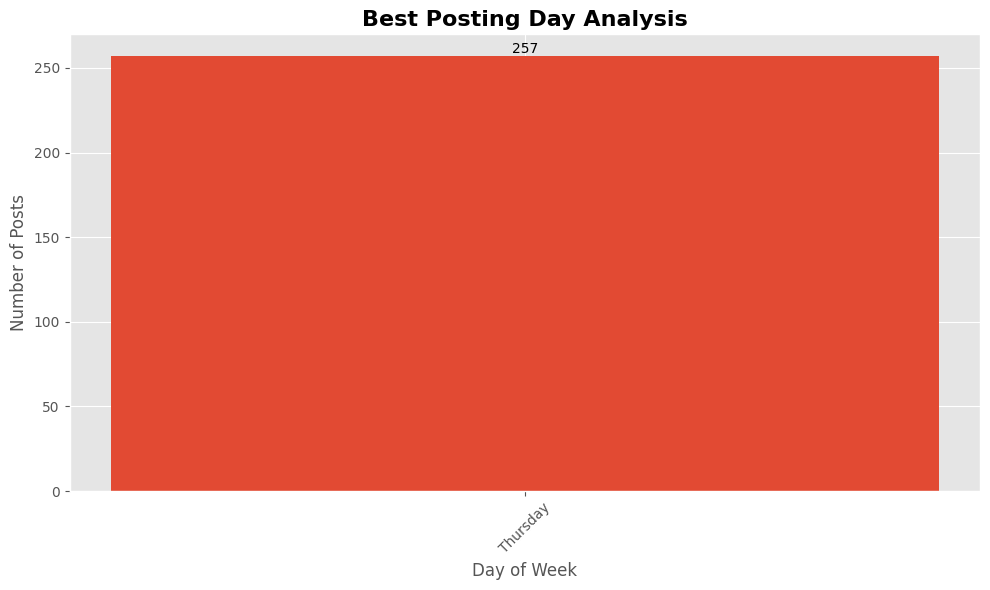

In [10]:
plt.figure(figsize=(10,6))

bars = plt.bar(posting_day.index, posting_day.values)

plt.title("Best Posting Day Analysis", fontsize=16, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Number of Posts")

for bar in bars:
    height = bar.get_height()

    if not pd.isna(height):      # Ignore NaN values
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{int(height)}",
            ha='center',
            va='bottom'
        )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

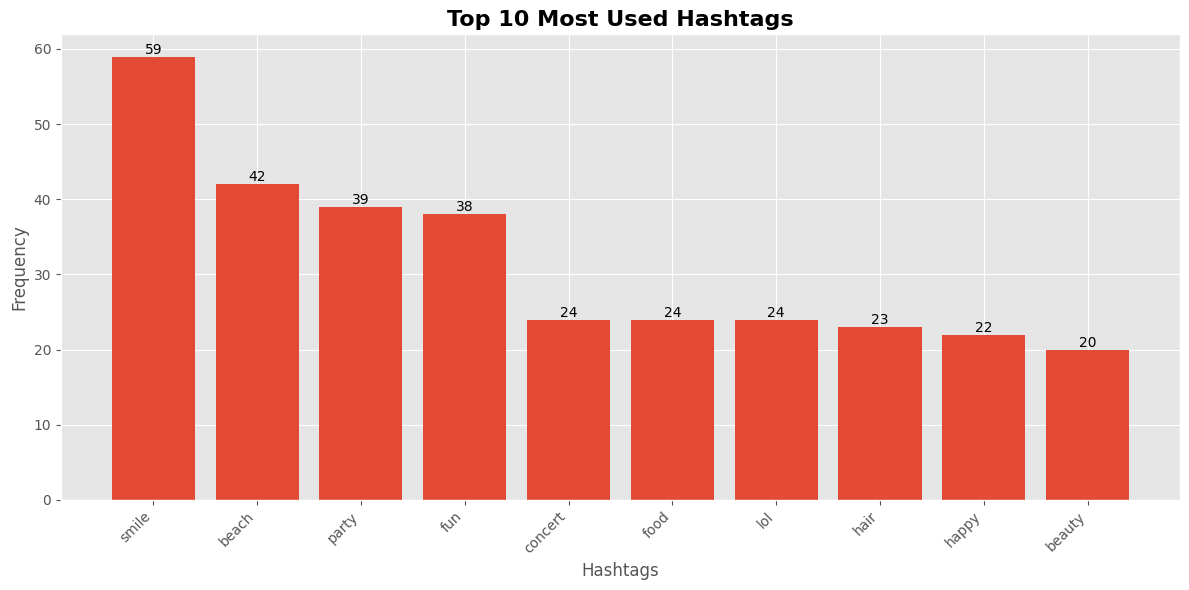

In [12]:
# Merge photo_tags with tags
hashtags = photo_tags.merge(
    tags,
    left_on='tag ID',
    right_on='id',
    how='left'
)

# Count hashtag usage
top_hashtags = (
    hashtags['tag text']
    .value_counts()
    .head(10)
)

# Plot
plt.figure(figsize=(12,6))

bars = plt.bar(top_hashtags.index, top_hashtags.values)

plt.title("Top 10 Most Used Hashtags", fontsize=16, fontweight='bold')
plt.xlabel("Hashtags")
plt.ylabel("Frequency")

plt.xticks(rotation=45, ha='right')

# Add labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

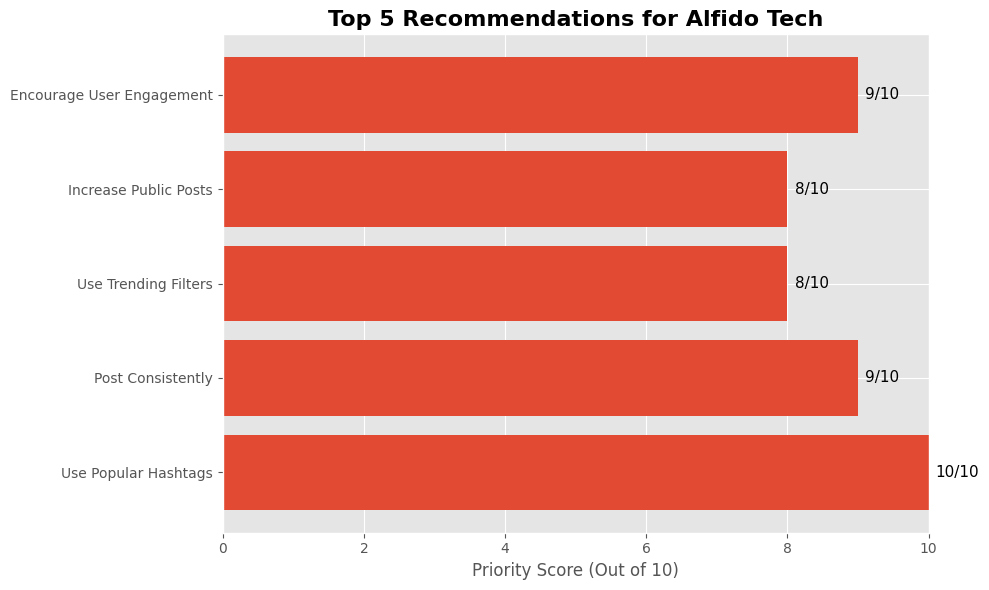

In [13]:
import matplotlib.pyplot as plt

# Recommendations
recommendations = [
    "Use Popular Hashtags",
    "Post Consistently",
    "Use Trending Filters",
    "Increase Public Posts",
    "Encourage User Engagement"
]

# Importance scores (for visualization)
scores = [10, 9, 8, 8, 9]

# Plot
plt.figure(figsize=(10,6))

bars = plt.barh(recommendations, scores)

plt.title("Top 5 Recommendations for Alfido Tech", fontsize=16, fontweight='bold')
plt.xlabel("Priority Score (Out of 10)")
plt.xlim(0, 10)

# Add score labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1,
             bar.get_y() + bar.get_height()/2,
             f"{width}/10",
             va='center',
             fontsize=11)

plt.tight_layout()
plt.show()

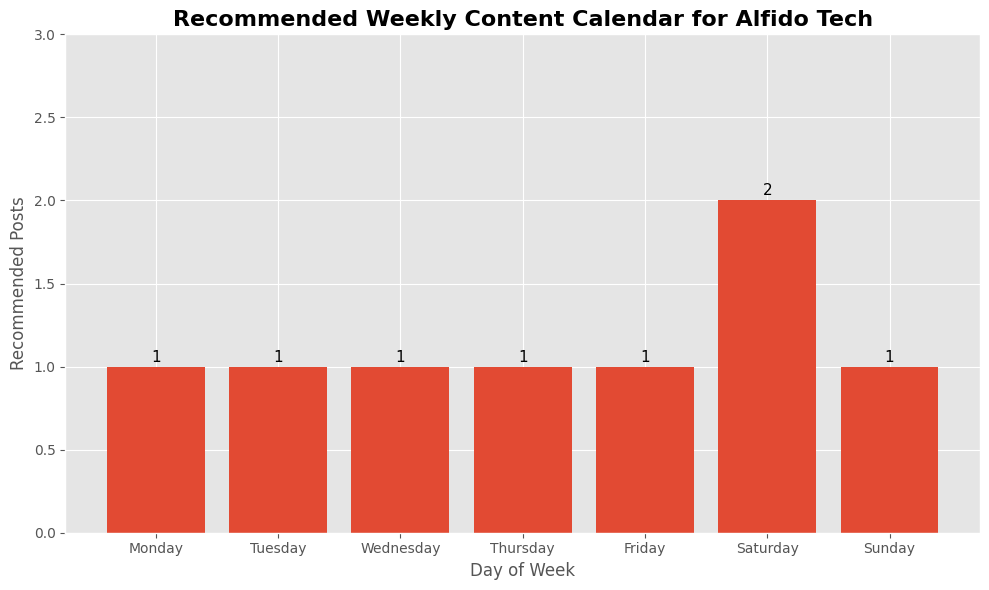

In [14]:
import matplotlib.pyplot as plt

# Weekly Content Calendar
days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Recommended number of posts
posts = [1, 1, 1, 1, 1, 2, 1]

plt.figure(figsize=(10,6))

bars = plt.bar(days, posts)

plt.title("Recommended Weekly Content Calendar for Alfido Tech",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Day of Week")
plt.ylabel("Recommended Posts")

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.03,
        str(int(height)),
        ha='center',
        fontsize=11
    )

plt.ylim(0,3)
plt.tight_layout()
plt.show()